# LYRA-Lite — 03 · Representation and Tokenization
*How a cell becomes model input. Defines and justifies the gene-token representation
and produces the Methods·Representation figures. Encoding logic lives in
`lyra_lite.data.representation`; this notebook orchestrates and visualises.*

## 0 · Setup & provenance
To ensure absolute reproducibility of the representation phase, we log the exact environmental state and configuration parameters before initializing the data structures.

In [2]:
# =========================================================
# 0 · Setup & provenance
# =========================================================
%load_ext autoreload
%autoreload 2

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from importlib.metadata import version
from plot_style import apply_paper_style, STYLE_COLORS
from IPython.display import Image, display
from lyra_lite.data.representation import encode_cells
import figures
apply_paper_style()

# --- data ---
CACHE = Path("../data/cache/cached_scpca_2000hvg_full.npz")
d = np.load(CACHE, allow_pickle=False)
X, y, groups, genes = d["X"], d["y"], d["groups"], d["genes"]
n_cells, n_hvgs = X.shape

# --- representation config (drives the worked examples below) ---
REP = {"top_k": 256, "ordering": "rank", "use_value": True, "pad_id": n_hvgs, "seed": 42}

print(f"cells {n_cells:,} | HVGs {n_hvgs} | patients {len(np.unique(groups))} | blast {y.mean():.1%}")
print("representation:", REP)
print("versions:", {p: version(p) for p in ("numpy", "pandas", "torch")})

cells 480,584 | HVGs 2000 | patients 84 | blast 86.9%
representation: {'top_k': 256, 'ordering': 'rank', 'use_value': True, 'pad_id': 2000, 'seed': 42}
versions: {'numpy': '2.4.6', 'pandas': '3.0.3', 'torch': '2.12.0'}


## 1 · Motivation — A Cell as a Sequence of Gene Tokens

The fundamental modeling premise of LYRA-Lite is the conceptual mapping of a biological entity to a linguistic one: a cell is represented by its set of expressed genes, analogous to a sentence composed of words. However, unlike natural language, the physical layout of mRNA transcripts within a sequencing droplet lacks intrinsic sequential ordering. Any imposed order (e.g., ranking by expression magnitude) is fundamentally an artificial inductive bias.

This permutation-invariance premise dictates our architectural choices and the design of the evaluation ladder. The **Transformer**, which utilizes parallel self-attention and is inherently permutation-invariant (prior to positional encodings), is the natural fit for this data modality. Conversely, the **LSTM**, which is strictly order-dependent, serves as the critical negative control. By feeding the exact same sequential representations into both architectures, the LSTM isolates and tests the validity of the permutation-invariance premise. 

The evaluation ladder strictly separates the input paradigms:
*   **FNN (Baseline):** Consumes the static, dense expression vector for all features.
*   **LSTM (Control) & Transformer (Target):** Consume the dynamic gene-token sequence defined by our encoding scheme.

## 2 · The Design Space

Translating a dense, highly sparse single-cell expression matrix into an efficient sequence requires a series of defensible, empirically grounded decisions. The table below outlines the design space, our selected approaches, and the underlying rationale.

| Design Dimension | Selected Approach | Rationale | Literature Precedent |
| :--- | :--- | :--- | :--- |
| **Input Format** | Gene Tokens (Sequence) | Enables attention mechanisms to model gene-gene interactions dynamically, overcoming the rigid sparsity of dense matrices. | scBERT, Geneformer |
| **Feature Representation** | Rank + Value | Pure rank models discard biological magnitude. By providing an explicit continuous value channel alongside the discrete gene ID token, we retain critical transcriptomic variance. | scGPT, scFoundation |
| **Sequence Length** | Capped at `top_k` | Single-cell RNA-seq data is exceedingly sparse. A cap retains the most biologically salient features while strictly bounding the computational complexity of self-attention. | Geneformer |
| **Sparsity Handling** | `PAD_ID` + Masking | Cells with expressed genes < `top_k` require padding to maintain tensor dimensions. Attention masking ensures mathematically inert padding that does not corrupt the representation. | Standard NLP paradigm |
| **Sequence Ordering** | Rank (Default) | Serves as the primary inductive bias. Random and ascending orderings serve as the explicit ablation levers to falsify order-dependence. | - |

## 3 · Empirical grounding & top_k sensitivity


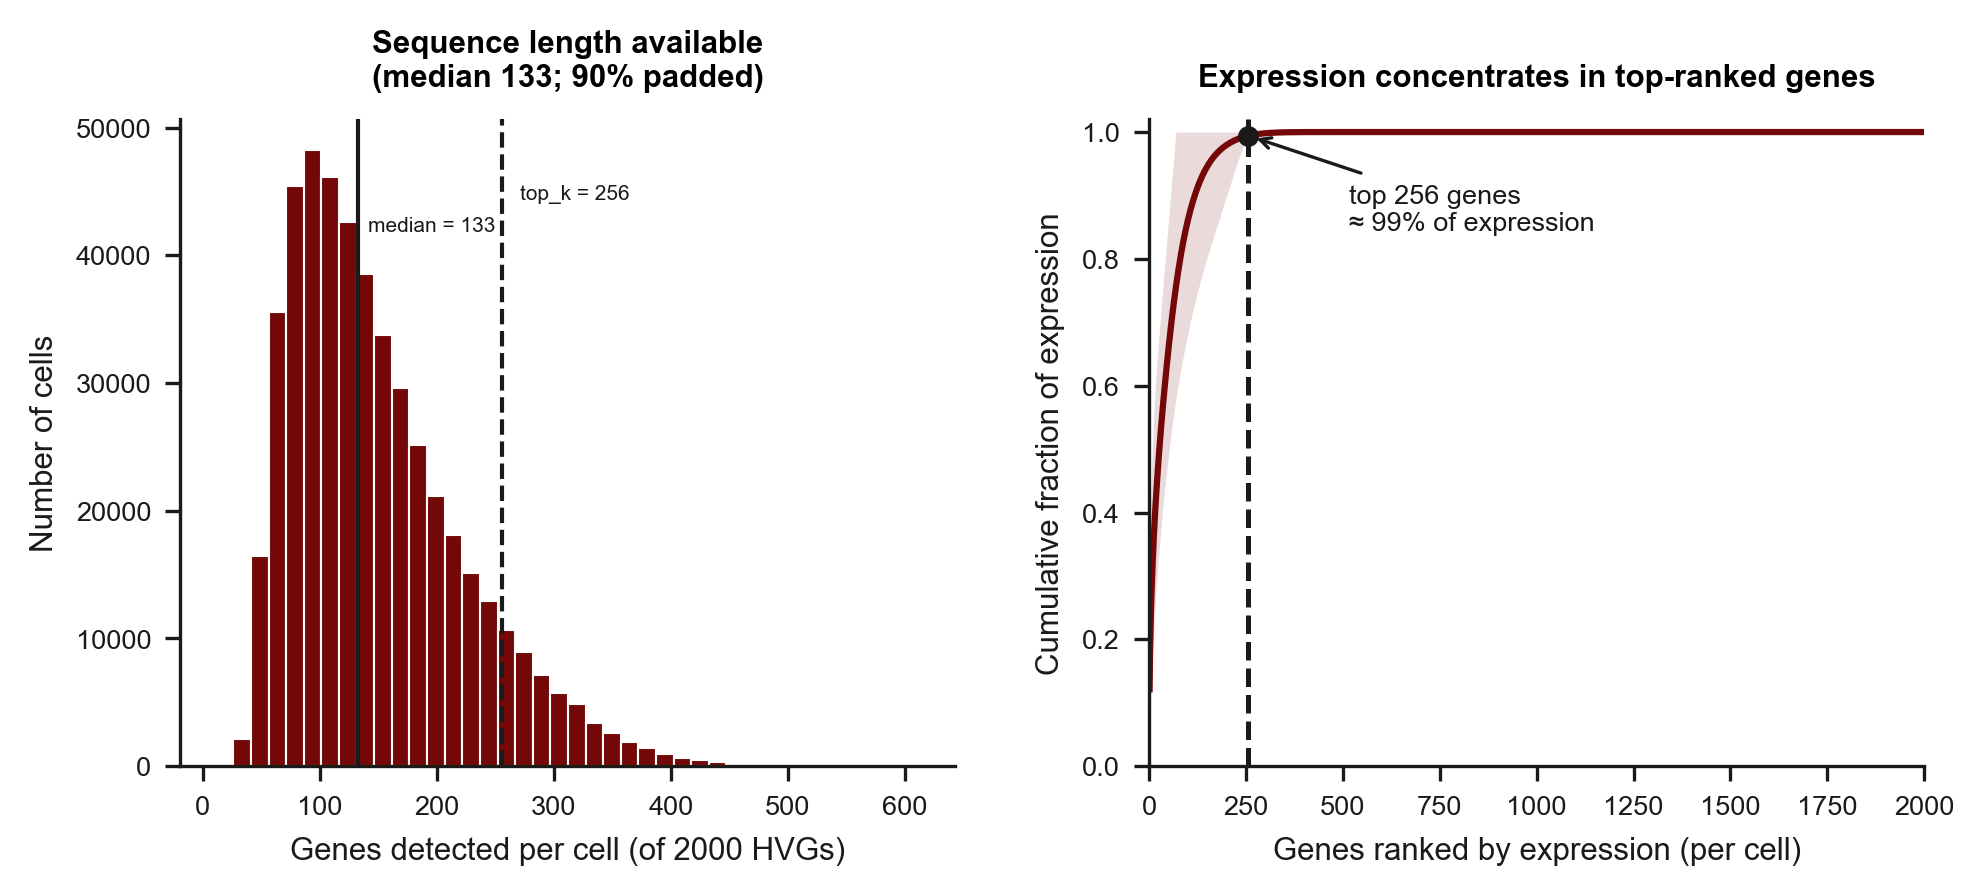

Figure loaded successfully from: figures/02c_token_statistics.png


In [3]:
fig_path = Path("figures/02c_token_statistics.png")

try:
    display(Image(filename=fig_path))
    print(f"Figure loaded successfully from: {fig_path}")
except FileNotFoundError:
    print(f"Could not find {fig_path}. Ensure notebook 02 was run and the image is saved.")



To justify capping our sequences at $K = 256$, we analyze the distribution of expressed genes per cell. Due to the inherent sparsity of single-cell RNA-seq data, only a fraction of the 2,000 Highly Variable Genes (HVGs) are actively expressed (non-zero counts) in any given cell. 

Empirically, we find that the **median number of detected genes per cell is 133**. This biological profile provides a strong twofold justification for our representation design:

1. **The Padding/Masking Choice:** Since ~90% of all cells express fewer than 256 genes, a cap of $K = 256$ safely captures the complete expressed repertoire of the vast majority of cells, with the remaining capacity handled via mathematically inert padding (`PAD_ID` + masking).
2. **Computational Efficiency:** Restricting the sequence length to $K = 256$ strictly bounds the quadratic complexity $O(K^2)$ of the self-attention mechanism, preventing computational bottlenecks without sacrificing biological signal.

The quantitative distribution of this sparsity and the cumulative transcriptomic mass captured are visualized above (computed and saved during the exploratory phase in Notebook 02).

## 4 · Worked example — one cell, fully transformed


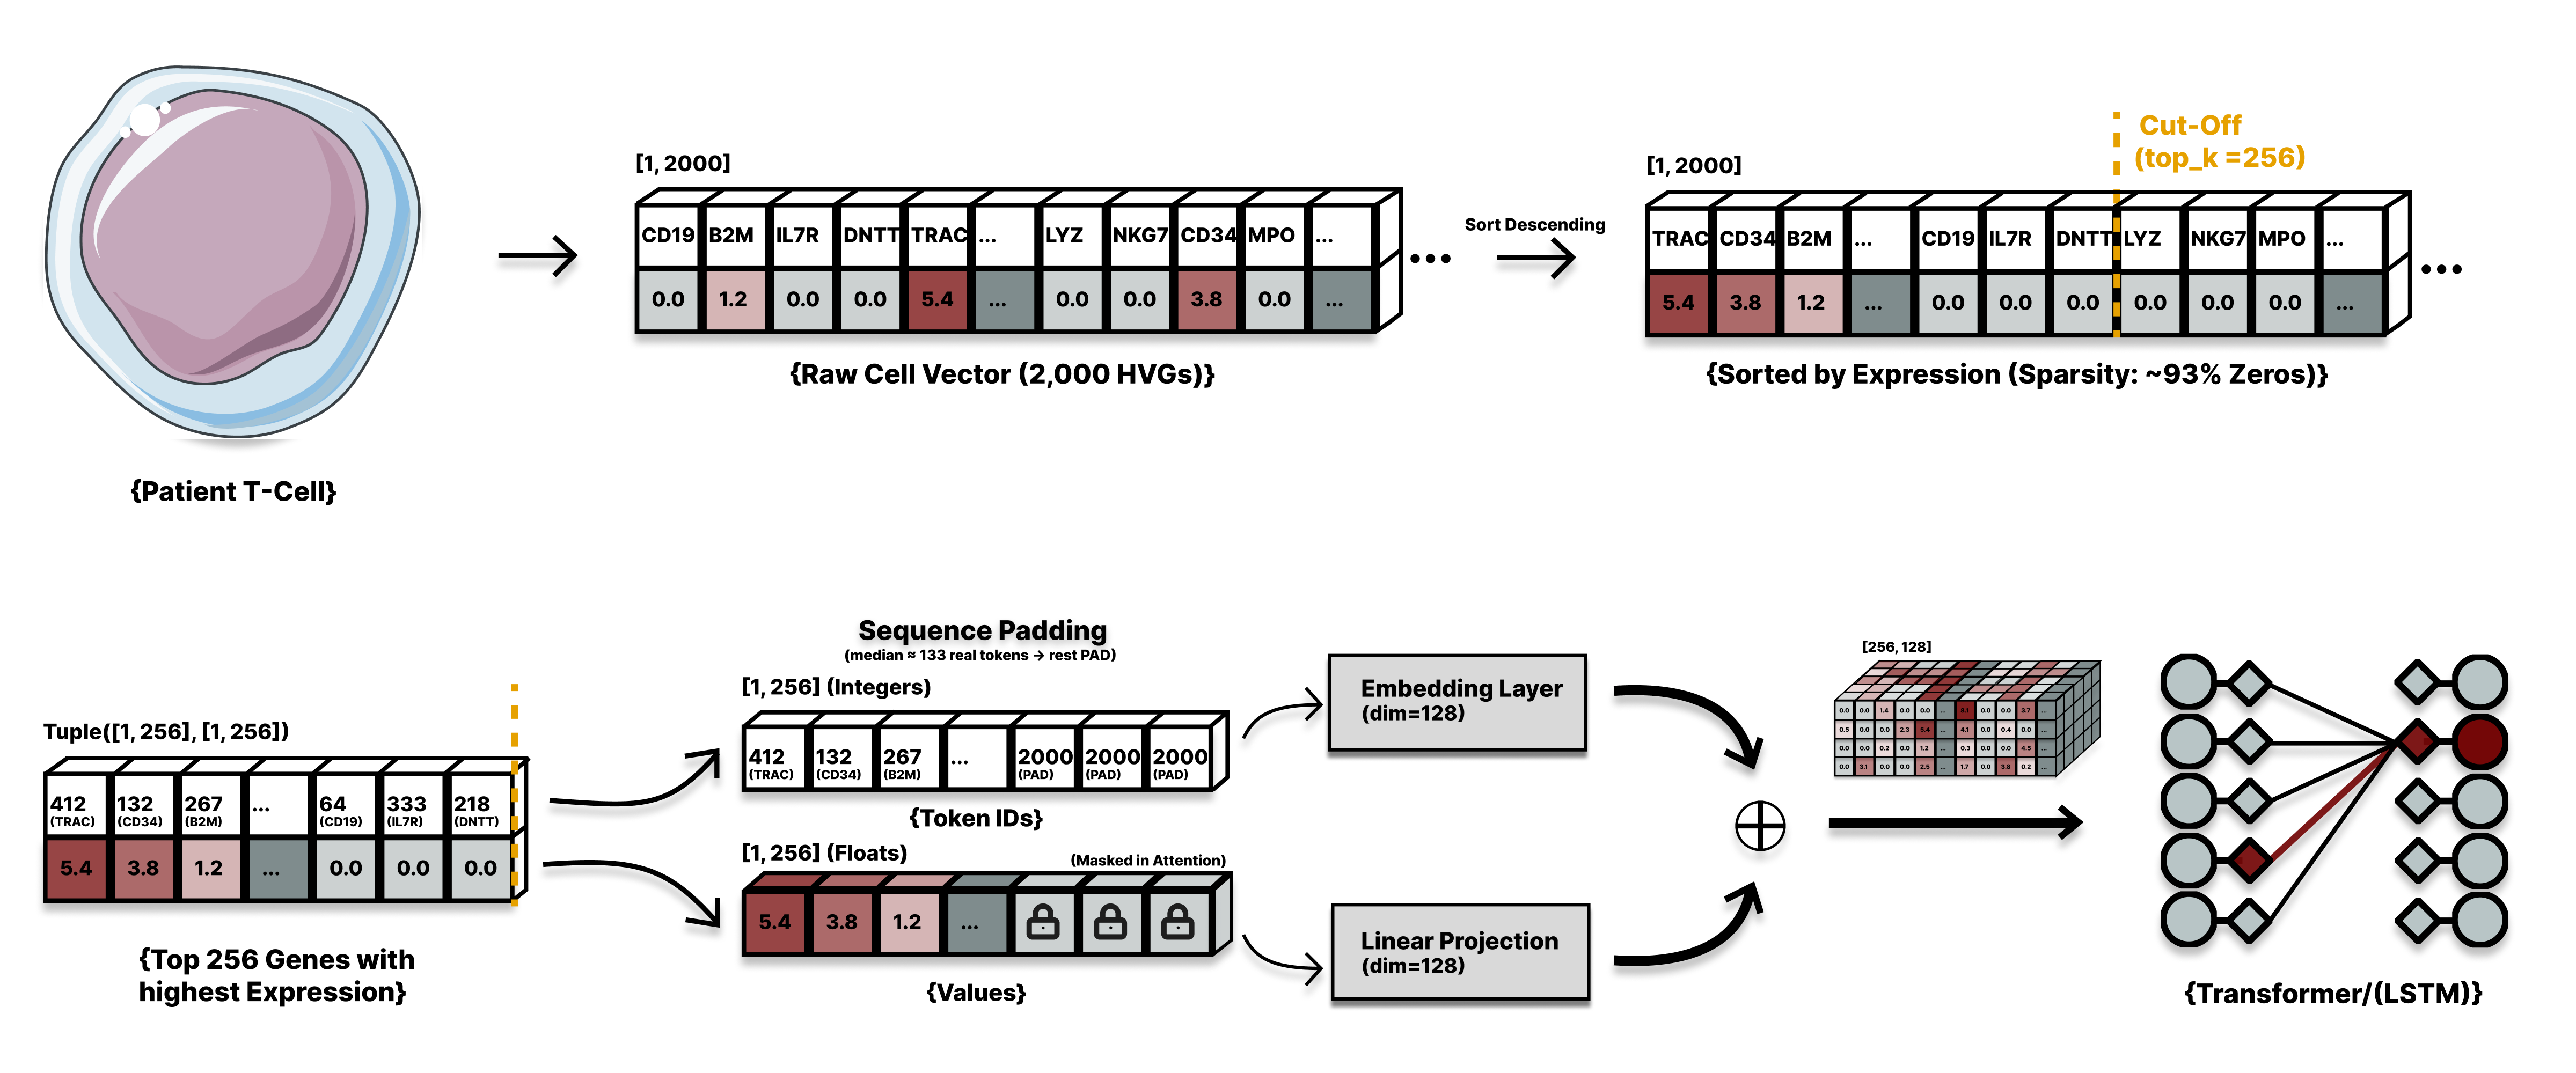

Figure loaded successfully from: figures/03_cell_representation.png


In [4]:
fig_path = Path("figures/03_cell_representation.png")

try:
    display(Image(filename=fig_path))
    print(f"Figure loaded successfully from: {fig_path}")
except FileNotFoundError:
    print(f"Could not find {fig_path}. Please ensure the file exists in the specified path.")


The diagram above illustrates the end-to-end processing pipeline, showing how raw single-cell transcriptomic profiles are transformed into structured, dual-channel token sequences optimized for sequence-to-sequence architectures:

1. **Raw Cell Vector:** For each individual cell, we begin with a sparse vector spanning $D = 2,000$ Highly Variable Genes (HVGs), annotated with cohort and biological metadata (e.g., patient cohort, tissue location, and diagnostic ground truth as blast or normal cells). Due to biological sparsity, approximately 93% of the features in this raw vector contain zero-expression values.

2. **Expression-Based Sorting:** To concentrate information density, genes are sorted in descending order based on their log-normalized expression magnitude. This re-ordering serves as our default rank-based inductive bias.

3. **Top-$K$ Selection (Cut-Off):** The sorted sequence is capped at $K = 256$ tokens. This step yields a paired tuple of vectors: a discrete integer index vector representing the global Gene Token IDs (ranging from $0$ to $1,999$), and a continuous float vector containing the corresponding log-normalized expression values.

4. **Sequence Padding & Attention Masking:** For cells expressing fewer than 256 genes (with a cohort median of 133 expressed genes), the vacant tail of the sequence is populated with a designated padding token ($\text{PAD\_ID} = 2000$). To prevent these inert tokens from corrupting self-attention computations, we generate a boolean attention mask. This mask forces the attention weights of padded positions to negative infinity ($-\infty$), setting their post-softmax attention coefficients to exactly $0$.

5. **Joint Representation Space (Embedding & Projection):**
   * **Gene Identity Channel:** The integer Token IDs are mapped through a learnable lookup table (Embedding Layer) to generate dense gene-identity vectors of dimension $d = 128$.
   * **Expression Magnitude Channel:** The continuous expression floats are mapped through a single-layer feed-forward network (Linear Projection Layer) into the same representation dimension $d = 128$.
   
   These two parallel tracks are combined via element-wise addition ($\oplus$), yielding a final unified tensor of shape $[256, 128]$ ready for downstream modeling via our LSTM (Control) or Transformer (Target) architectures.

## 5 · Sequence Ordering and Positional Inductive Bias

In traditional NLP, sequence order is everything. It's what encodes syntax and semantic meaning. A cell, however, is essentially a "bag-of-genes" (an unordered co-occurrence set), which means any sequence order we impose on it is inherently arbitrary. 

This structural difference actually gives us a rare, exciting opportunity to isolate exactly what sequence order *contributes* to a classifier. This is a question that is incredibly hard to test in natural language, because scrambling word order immediately destroys the meaning of a sentence. 

To probe this, we impose the following ordering regimes on our token sequences:
1. **Rank-Ordered (Default):** Sorted descending by expression magnitude.

2. **Randomly Ordered:** Shuffled per sequence to destroy any position↔content coupling.

3. **Ascending:** The same tokens as rank, direction reversed, so the highest-expression gene lands in the LSTM's final-hidden **recency slot** — a controlled recency probe.

---

### 5.1 What each model tells us

We use these ordering permutations to run a two-sided structural test across our models:

* **The LSTM (Order-Sensitive Control):**
  Since an LSTM lacks permutation invariance, its predictions *can* change depending on the input order and we want to test whether they actually do. 
  There is a subtle nuance here: because our dual-channel input already carries expression magnitude in its continuous value channel, the rank-ordered sorting might actually be redundant. If that is true, the LSTM might prove surprisingly robust to shuffling, which would itself be strong evidence that sequence order adds no signal beyond the raw token set. If we see a significant drop under random order, it proves the LSTM is relying heavily on position to make sense of the data. (This effect should be strongest under pure-rank encoding, where token position is the only cue for magnitude).

* **The Transformer without PE (The Invariance Anchor):**
  With positional encodings disabled and symmetric pooling, this model is permutation-invariant *by construction*. Its outputs across all orderings must be identical down to float precision. 
  
  Because of this, we treat this model's performance not as a biological or architectural finding, but purely as an **implementation sanity check**. If the outputs are identical, it confirms that no accidental positional cues are leaking through our architecture.

* **The Transformer with PE (The Substantive Test):**
  Enabling sinusoidal positional encodings grants the Transformer access to token positions. 
  
  By comparing this setup to the non-PE baseline on rank-ordered inputs, we can test whether sequence order provides any useful signal at all. If we see no performance gain (or even a loss), it indicates that permutation invariance is the correct inductive bias for this data, and that positional encodings are redundant when a dedicated expression value channel is present. 
  
  As a secondary probe, pairing PE with random ordering forces the model to process meaningless positions. Whether its performance degrades or it simply learns to ignore the noisy coordinates will tell us a lot about how heavily the architecture relies on order.

By combining the LSTM (varying the order an order-sensitive model sees) and the PE-equipped Transformer (giving an order-invariant model access to spatial coordinates), we form a highly rigorous, two-sided test of a single, fundamental question: *Is sequential order a useful signal for a bag-of-genes?*

In [5]:
preview = figures.plot_ablation_preview(X, REP)

print("Inputs passed to the models' embedding layers under ablation [Format: Token (Expression)]:")
display(preview)

Inputs passed to the models' embedding layers under ablation [Format: Token (Expression)]:


,Rank-Ordered (Default),Ascending (recency probe),Randomized (Permuted)
0,Token 1647 (2.21),Token 952 (0.54),Token 1105 (0.54)
1,Token 1460 (2.06),Token 1964 (0.54),Token 1261 (0.54)
2,Token 1368 (1.89),Token 1015 (0.54),Token 1260 (1.49)
3,Token 271 (1.89),Token 1962 (0.54),Token 1932 (0.54)
4,Token 1058 (1.70),Token 1961 (0.54),Token 524 (0.54)


## 6 · Corpus Statistics: The "Gene Language" Perspective

To evaluate single-cell transcriptomics through an NLP lens, we must analyze our dataset not as a biological matrix, but as a text corpus. In this analogy, **individual cells function as documents**, and **expressed genes act as active vocabulary tokens**. 

By treating our dataset as a corpus, we can extract standard NLP linguistic properties to understand our vocabulary dynamics before training:

---

### 1. Vocabulary Size & Dictionary Limits
*   **Active Vocabulary ($V$):** $2,000$ unique tokens (our Highly Variable Genes, $D = 2000$).
*   **Special Tokens:** We introduce exactly one structural token, the padding token ($\text{PAD\_ID} = 2000$), bringing our total operational vocabulary size to $|V| = 2,001$.

### 2. Document Length Distribution (Sequence Sparsity)
In NLP, document length variation dictates batching and padding overhead. In our corpus, while our maximum sequence capacity is capped at $K = 256$ (the model's context window), the *true* document length (the number of actually expressed genes per cell) varies dynamically. 

Analyzing this distribution reveals our **corpus density**:
*   **Median Sequence Length:** $\sim 133$ active tokens.
*   **Padding Overhead:** With a median of 133 real tokens, approximately $48\%$ of our input tensor space consists of $\text{PAD}$ tokens. This highlights the crucial role of our attention masking strategy to prevent the model from focusing on empty padding states.

### 3. Token-Frequency Distribution (Zipf's Law Analogy)
In natural language, token frequencies follow Zipf's Law (a few "stop words" like *the*, *and*, *is* dominate the corpus, while most words are extremely rare). Our "gene language" exhibits a strikingly similar distribution:

*   **High-Frequency "Stop Words" (Housekeeping Genes):** Certain tokens appear in almost every single document (cell) regardless of class. These represent fundamental cellular machinery (e.g., ribosomal proteins or actin). In NLP terms, these function like structural stop words—highly frequent, but carrying low discriminative signal for our classification task.
*   **Low-Frequency "Content Words" (Discriminative Genes):** Highly specialized tokens appear rarely and only in specific cell subsets (e.g., specific lineage markers or oncogenes in blasts). These carry the actual semantic weight needed for sequence classification, mimicking rare, highly descriptive nouns in a text corpus.